In [1]:
# Install dependencies as needed:
# 
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "btcusd_1-min_data.csv"
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "mczielinski/bitcoin-historical-data",
  file_path,
)

print("First 5 records:", df.head())

C:\Users\aseelappumud\AppData\Local\Temp\ipykernel_33224\1463961650.py:7: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 369M/369M [00:23<00:00, 16.7MB/s] 


First 5 records:     Timestamp  Open  High   Low  Close  Volume
0  1325376060  4.58  4.58  4.58   4.58     0.0
1  1325376120  4.58  4.58  4.58   4.58     0.0
2  1325376180  4.58  4.58  4.58   4.58     0.0
3  1325376240  4.58  4.58  4.58   4.58     0.0
4  1325376300  4.58  4.58  4.58   4.58     0.0


In [14]:
df["Datetime"] = pd.to_datetime(df["Timestamp"], unit="s", utc=True)
df_filtered = df[
    (df["Datetime"] >= "2017-01-01") &
    (df["Datetime"] < "2026-04-30")
].copy()
df_filtered

,Timestamp,Open,High,Low,Close,Volume,Datetime
2630879,1483228800,966.30,966.30,966.30,966.30,0.000000,2017-01-01 00:00:00+00:00
2630880,1483228860,966.34,966.34,966.34,966.34,7.610000,2017-01-01 00:01:00+00:00
2630881,1483228920,966.16,966.37,966.16,966.37,8.087376,2017-01-01 00:02:00+00:00
2630882,1483228980,966.37,966.37,966.37,966.37,0.000000,2017-01-01 00:03:00+00:00
2630883,1483229040,966.37,966.37,966.37,966.37,0.000000,2017-01-01 00:04:00+00:00
...,...,...,...,...,...,...,...
7535514,1777506900,75784.00,75789.00,75784.00,75788.00,0.025788,2026-04-29 23:55:00+00:00
7535515,1777506960,75787.00,75791.00,75786.00,75787.00,0.088334,2026-04-29 23:56:00+00:00
7535516,1777507020,75779.00,75779.00,75779.00,75779.00,0.001847,2026-04-29 23:57:00+00:00
7535517,1777507080,75774.00,75784.00,75774.00,75779.00,0.078122,2026-04-29 23:58:00+00:00


In [15]:
df_filtered  = df_filtered[["Datetime", "Open", "High", "Close", "Low", "Volume"]]
df_filtered.head()

,Datetime,Open,High,Close,Low,Volume
2630879,2017-01-01 00:00:00+00:00,966.30,966.30,966.30,966.30,0.000000
2630880,2017-01-01 00:01:00+00:00,966.34,966.34,966.34,966.34,7.610000
2630881,2017-01-01 00:02:00+00:00,966.16,966.37,966.37,966.16,8.087376
2630882,2017-01-01 00:03:00+00:00,966.37,966.37,966.37,966.37,0.000000
2630883,2017-01-01 00:04:00+00:00,966.37,966.37,966.37,966.37,0.000000


In [16]:
df_filtered = df_filtered.reset_index(drop=True)
df_filtered.head()

,Datetime,Open,High,Close,Low,Volume
0,2017-01-01 00:00:00+00:00,966.30,966.30,966.30,966.30,0.000000
1,2017-01-01 00:01:00+00:00,966.34,966.34,966.34,966.34,7.610000
2,2017-01-01 00:02:00+00:00,966.16,966.37,966.37,966.16,8.087376
3,2017-01-01 00:03:00+00:00,966.37,966.37,966.37,966.37,0.000000
4,2017-01-01 00:04:00+00:00,966.37,966.37,966.37,966.37,0.000000


In [17]:
import pandas as pd

# make sure Datetime is proper datetime
df_filtered["Datetime"] = pd.to_datetime(df_filtered["Datetime"], utc=True)

# set as index
df_hourly = (
    df_filtered
    .set_index("Datetime")
    .resample("1h")
    .agg({
        "Open": "first",
        "High": "max",
        "Low": "min",
        "Close": "last",
        "Volume": "sum"
    })
    .dropna()
    .reset_index()
)

print(df_hourly.head())
print(df_hourly.shape)

                   Datetime    Open    High     Low   Close      Volume
0 2017-01-01 00:00:00+00:00  966.30  966.99  964.60  966.60  102.484806
1 2017-01-01 01:00:00+00:00  966.60  966.60  962.54  963.87  149.025554
2 2017-01-01 02:00:00+00:00  964.35  965.75  961.99  963.97   94.267396
3 2017-01-01 03:00:00+00:00  963.97  964.71  960.53  962.83   77.619667
4 2017-01-01 04:00:00+00:00  960.61  963.64  960.60  963.46   46.810220
(81744, 6)


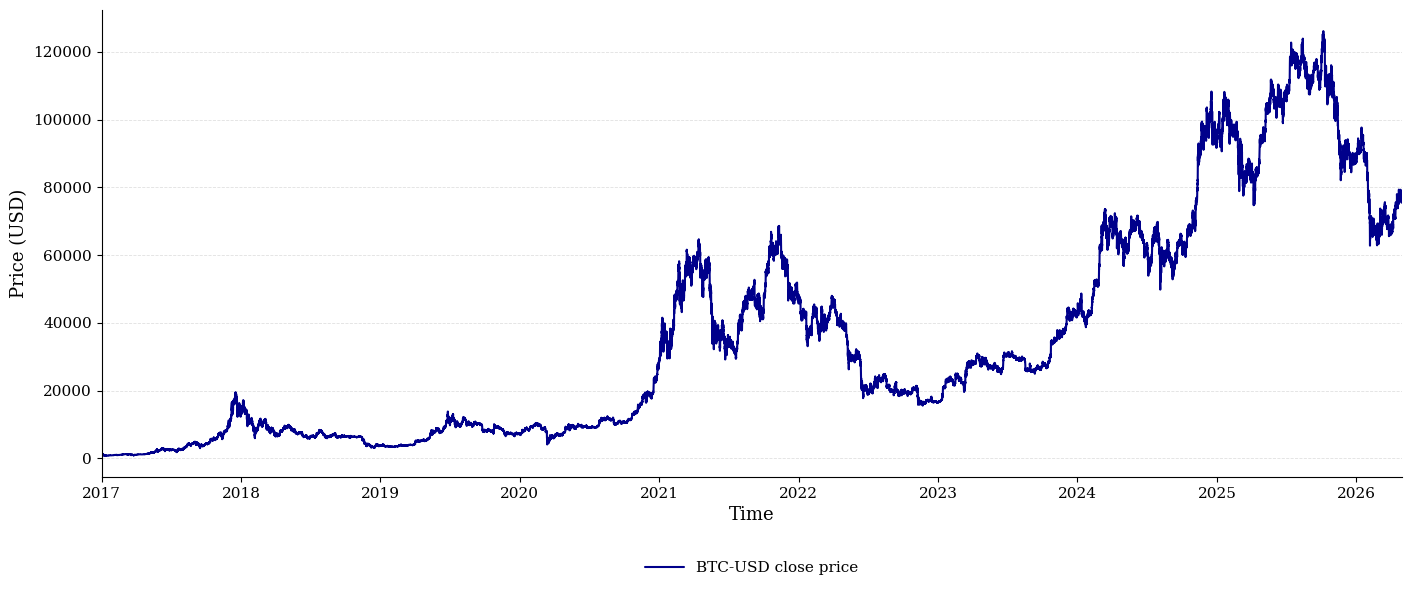

In [19]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.titlesize": 16,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "axes.facecolor": "white",
    "figure.facecolor": "white",
    "axes.edgecolor": "black",
    "axes.linewidth": 0.8,
    "grid.color": "#D9D9D9",
    "grid.linestyle": "--",
    "grid.linewidth": 0.6,
    "lines.solid_capstyle": "round",
    "savefig.dpi": 600,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

fig, ax = plt.subplots(figsize=(14, 5.8), constrained_layout=True)

ax.plot(
    df_hourly["Datetime"],
    df_hourly["Close"],
    color="#00008B",          
    linewidth=1.5,
    label="BTC-USD close price",
    zorder=2
)

# Labels
ax.set_xlabel("Time")
ax.set_ylabel("Price (USD)")

# Optional title (uncomment if needed)
# ax.set_title("BTC-USD hourly closing prices with detected change points")

# Grid: only horizontal, subtle
ax.grid(True, axis="y", alpha=0.8)
ax.grid(False, axis="x")

# Remove unnecessary spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Date formatting
locator = mdates.AutoDateLocator(minticks=6, maxticks=10)
formatter = mdates.ConciseDateFormatter(locator)
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(formatter)

# Limits and margins
ax.set_xlim(df_hourly["Datetime"].min(), df_hourly["Datetime"].max())
ax.margins(x=0)

# Legend
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=2,
    frameon=False,
    handlelength=2.5
)

plt.show()

In [ ]:
df_hourly.to_excel("BTC-hourly-data closing price